Duilio Lucio, Vivian Hu

Spring 2026

CS 343: Neural Networks

Project 2: Multi-layer Perceptrons

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# for preprocessing dataset
import preprocess_data

# Set the color style so that Professor Layton can see your plots
plt.show()
plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
# Make the font size larger
plt.rcParams.update({'font.size': 20})

# Turn off scientific notation when printing
np.set_printoptions(suppress=True, precision=3)

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

## Task 2: Implement single layer network to test softmax activation and cross-entropy loss

You will first implement and test out the softmax activation and cross-entropy loss in a single layer net before embedding it in a more complex multi-layer network.

### 2a. Load in preprocessed STL-10 data

Use your automated preprocessing function to load in the STL-10 data in the following split:
- 3000 training samples
- 750 test samples
- 1000 validation samples
- 250 samples for development

In [6]:
# YOUR CODE HERE
x_train, y_train, x_test, y_test, x_val, y_val, x_dev, y_dev = preprocess_data.load_stl10(n_train_samps=3000, 
                                                                                          n_test_samps=750, 
                                                                                          n_valid_samps=1000, 
                                                                                          n_dev_samps=250)
# Print statements
print("x_train:", x_train.shape, "y_train", y_train.shape, "labels:", y_train.min(), y_train.max())
print("x_test:", x_test.shape, "y_test:", y_test.shape)
print("x_val:", x_val.shape, "y_val:", y_val.shape)
print("x_dev:", x_dev.shape, "y_dev:", y_dev.shape)

Found cached numpy arrays the images and labels. Loading them...
Images are: (5000, 32, 32, 3)
Labels are: (5000,)
x_train: (3000, 3072) y_train (3000,) labels: 0 9
x_test: (750, 3072) y_test: (750,)
x_val: (1000, 3072) y_val: (1000,)
x_dev: (250, 3072) y_dev: (250,)


### 2b. Implement the following functions

In `softmax_layer.py`, implement the following methods in the base class `SoftmaxLayer`:

- `fit`
- `net_in`
- `predict`
- `one_hot`
- `accuracy`
- `activation` (softmax) $f(x_i) = \frac{e^{x_i}}{\sum_{j=1}^C e^{x_j}}$ where $x_i$ are the "net in" values and there are $C$ output neurons (one per input class). $f(x_i)$ is the activation values of each output neuron $i$. Since this is softmax, it is the probability that a given input belongs to the class $i$ coded by the output neuron.
- `loss` (cross-entropy) $L(x_m) = -\frac{1}{B}\sum_{b=1}^B{Log \left (\frac{e^{x_m}}{\sum_{n=1}^C e^{x_n}}\right )}$. $m$ is the correct class for the $b^{th}$ input. $x_m$ is the output neuron activation for the correct class, $x_n$ is the output neuron activation for all of the classes (in the sum). The batch size is $B$, so the loss is averaged over each mini-batch of inputs. The expression in the $Log$ is just the softmax.
- `gradient` (for softmax/cross-entropy)

You're welcome to work in any order, but I recommend starting with `fit` because as you work though it, you should recognize why we need most of the other methods. You can finish `fit` or branch off as you need the other methods.

### 2c. Test key functions

In [7]:
from softmax_layer import SoftmaxLayer

In [8]:
# Let's generate some small Gaussian weights equal to the length of an image feature vector
rng = np.random.default_rng(0)
randWts = rng.normal(loc=0, scale=0.01, size=(x_dev.shape[1], 10))
b = 1
softmaxNet = SoftmaxLayer(-1)

# Fake data for consistent debugging
test_imgs = rng.random(size=(15, x_dev.shape[1])) - 0.5
test_labels = rng.integers(low=0, high=6, size=(15,))

#### Test the `onehot` function

In [9]:
y_test1 = np.array([1, 2, 2, 0, 1, 3])
c_test = 4
y_one_hot = softmaxNet.one_hot(y_test1, c_test)
print(f'Your one hot vectors:\n{y_one_hot}')

Your one hot vectors:
[[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]]


Your one hot vectors should look like:

    [[0. 1. 0. 0.]
     [0. 0. 1. 0.]
     [0. 0. 1. 0.]
     [1. 0. 0. 0.]
     [0. 1. 0. 0.]
     [0. 0. 0. 1.]]

#### Test the `loss`,  `net_in`, softmax `activation` functions

In [10]:
lossNoReg, lossReg = softmaxNet.test_loss(randWts, b, test_imgs, test_labels)
print(f'The loss (without regularization) is {lossNoReg:.2f} and it should approx be 2.30')
print(f'The loss (with 0.5 regularization) is {lossReg:.2f} and it should approx be 3.07')

net in shape=(15, 10), min=0.5846647992996103, max=1.4113966700992964
Should be
net in shape=(15, 10), min=0.584664799299611, max=1.411396670099296

net act shape=(15, 10), min=0.06651346722629758, max=0.14392819816212585
Should be
net act shape=(15, 10), min=0.0665134672262976, max=0.1439281981621258

The loss (without regularization) is 2.30 and it should approx be 2.30
The loss (with 0.5 regularization) is 3.07 and it should approx be 3.07


#### Test the `gradient` function

In [11]:
grad_wts, grad_b = softmaxNet.test_gradient(randWts, b, test_imgs, test_labels, 10)
print()
print(f'1st few Wt gradient values are {grad_wts[:4,0]}\nand should be                  [ 0.009 -0.047  0.088  0.01 ] ')
print(f'1st few Wt bias values are {grad_b[:4]}\nand should be              [-0.429  0.034  0.034 -0.098]')

net in: (15, 10), 0.5846647992996103, 1.4113966700992964
net in 1st few values of 1st input are:
[0.798 1.095 0.969 0.9   0.958]
and should be
[0.798 1.095 0.969 0.9   0.958]
net act 1st few values of 1st input are:
[0.078 0.105 0.092 0.086 0.091]
and should be
[0.078 0.105 0.092 0.086 0.091]
y one hot: (15, 10), sum is 15.0.
You should know what the sum should be :)

1st few Wt gradient values are [ 0.009 -0.047  0.088  0.01 ]
and should be                  [ 0.009 -0.047  0.088  0.01 ] 
1st few Wt bias values are [-0.429  0.034  0.034 -0.098]
and should be              [-0.429  0.034  0.034 -0.098]


#### Test `fit` function

In [13]:
softmaxNet = SoftmaxLayer(10)
loss_history = softmaxNet.fit(x_dev, y_dev,
                              n_epochs=600,
                              mini_batch_sz=250,
                              r_seed=0)

0 9
N250, M=3072, C=10
mini_batch_sz=250 -> iters/epoch=1, total iters=600
iter    100/600 | epoch 100/600 | loss 2.2160
iter    200/600 | epoch 200/600 | loss 2.0538
iter    300/600 | epoch 300/600 | loss 1.9409
iter    400/600 | epoch 400/600 | loss 1.8616
iter    500/600 | epoch 500/600 | loss 1.9017
iter    600/600 | epoch 600/600 | loss 1.7528


Given the random mini-batch sampling process, you may get different specific numbers, but the loss should generally decrease over iterations. You should get something like this:

```
Starting to train network...There will be 600 epochs and 600 iterations total, 1 iter/epoch.
  Completed iter 0/600. Training loss: 2.37.
  Completed iter 100/600. Training loss: 2.12.
  Completed iter 200/600. Training loss: 2.01.
  Completed iter 300/600. Training loss: 1.91.
  Completed iter 400/600. Training loss: 1.87.
  Completed iter 500/600. Training loss: 1.79.
Finished training!
```

##### Plot the loss

It should look noisy, but decrease on average.

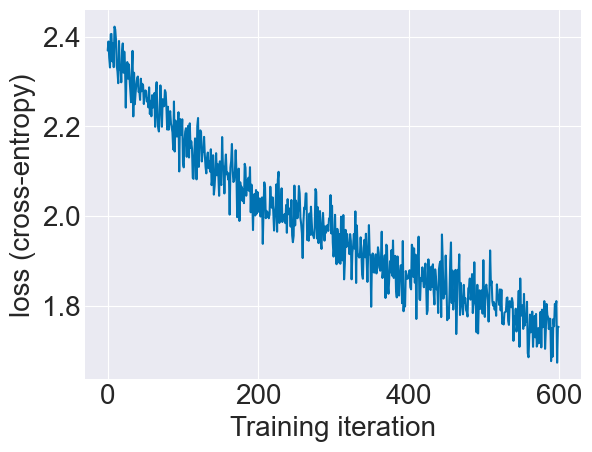

In [14]:
def plot_cross_entropy_loss(loss_history):
    plt.plot(loss_history)
    plt.xlabel('Training iteration')
    plt.ylabel('loss (cross-entropy)')
    plt.show()

plot_cross_entropy_loss(loss_history)

### 2d. Questions

**Question 1.** What do you think the decrease in loss over the epochs tells us about the state of the training process? What's the future potential for improvement like?

**Answer 1:**

The decrease in loss over the epochs tells us that the state of the training process is learning, and as long as learning is processing then the network is assigning higher probability to the correct class on average, thus the average is getting smaller. The amount of noise is expected with SGD because each mini-batch is updated based on a random sample of data, so the loss on any single batch can jump up or down while the average direction improves. The future potential for improvement could look like increasing epochs, tuning the learning rate, we can also increase model capacity, or also tune regularization.


**Question 2.** Below, write code to test regularization with training: check to make sure that the loss starts at ~155 for `reg=100`. Once you get this working, play around with the regularization parameter. You can drastically change the magnitude, but it should always remain nonnegative. 

(i) How does regularization affect the training loss and **why**?

(ii) Make a plot that shows the ~155 initial loss for `reg=100`.

**Answer 2:**

**i)** Regularization affects the training loss since it adds a penalty term proportional to the magnitude the model weights especially with L2 regularization adding (reg/2) ∑W^2 to the loss. When the reg. parameter is large then the penalty becomes significant and then it increases the total loss largely which is done to prevent overfitting from occurring and encourages the model to learn simple decision boundaries. As training progresses then the optimizer balances minimizing prediction error and weight magnitude. 

N250, M=3072, C=10
mini_batch_sz=250 -> iters/epoch=1, total iters=600
iter    100/600 | epoch 100/600 | loss 23.0999
iter    200/600 | epoch 200/600 | loss 5.0064
iter    300/600 | epoch 300/600 | loss 2.5634
iter    400/600 | epoch 400/600 | loss 2.2401
iter    500/600 | epoch 500/600 | loss 2.2247
iter    600/600 | epoch 600/600 | loss 2.1779


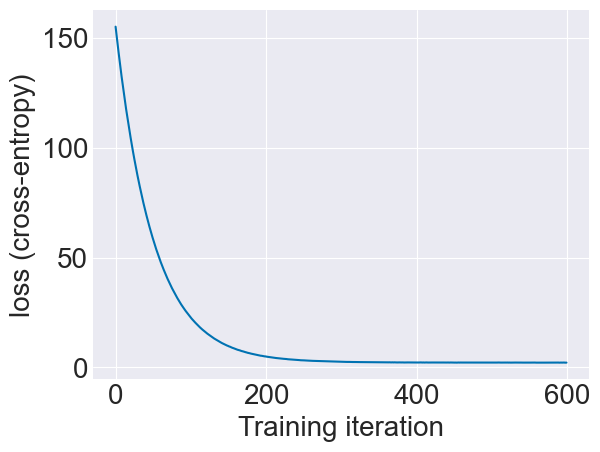

Initial Loss: 155.3245925959024


In [15]:
# YOUR CODE HERE
softmaxNet_reg = SoftmaxLayer(10)
loss_history_reg = softmaxNet.fit(
    x_dev,
    y_dev,
    n_epochs=600,
    mini_batch_sz=250, 
    reg=100,
    r_seed=0
)
# Plotting loss curve
plot_cross_entropy_loss(loss_history_reg)
# Print first loss val.
print("Initial Loss:", loss_history_reg[0])



**Question 3.** Play around with the batch size parameter, all while keeping the number of epochs the same.

(i) How does your choice of batch size affect your final training loss? **Why**? (*Think about the error gradient and how the weights change*)

(ii) How does this affect the overall appearance of the training loss curve? **Why**?

(iii) Make a plot that showcases the effect of large mini-batch size.

(iv) Make a plot that showcases the effect of small mini-batch size.

**Answer 3:**

**i)** batch size affects how the gradient is estimated. Small batch sizes produces more noise since they use fewer samples which leads to more fluctuating weight updates. On the contrary, larger batch sizes produce less noise, and provide more stable updates by computing gradients using more samples. Small batches may sometimes reach slightly lower loss, while large batches tend to converge more steadily.

**ii)** Small batch sizes make the loss curve noisier because each update is based on a small random subset of data. Large batch sizes produce a smoother loss curve because the gradient is averaged over more samples.

N250, M=3072, C=10
mini_batch_sz=250 -> iters/epoch=1, total iters=600
iter    100/600 | epoch 100/600 | loss 2.2160
iter    200/600 | epoch 200/600 | loss 2.0538
iter    300/600 | epoch 300/600 | loss 1.9409
iter    400/600 | epoch 400/600 | loss 1.8616
iter    500/600 | epoch 500/600 | loss 1.9017
iter    600/600 | epoch 600/600 | loss 1.7528
N250, M=3072, C=10
mini_batch_sz=10 -> iters/epoch=25, total iters=15000
iter    100/15000 | epoch   4/600 | loss 2.2235
iter    200/15000 | epoch   8/600 | loss 2.2628
iter    300/15000 | epoch  12/600 | loss 1.8074
iter    400/15000 | epoch  16/600 | loss 1.5098
iter    500/15000 | epoch  20/600 | loss 1.7907
iter    600/15000 | epoch  24/600 | loss 1.7063
iter    700/15000 | epoch  28/600 | loss 1.3852
iter    800/15000 | epoch  32/600 | loss 1.4175
iter    900/15000 | epoch  36/600 | loss 1.9807
iter   1000/15000 | epoch  40/600 | loss 1.9426
iter   1100/15000 | epoch  44/600 | loss 1.6715
iter   1200/15000 | epoch  48/600 | loss 1.6239
iter

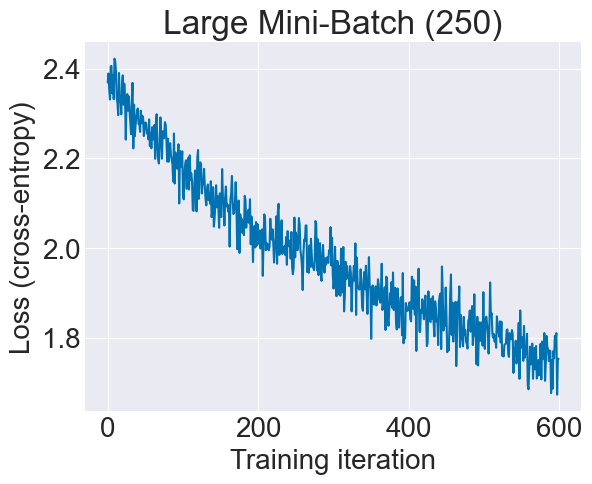

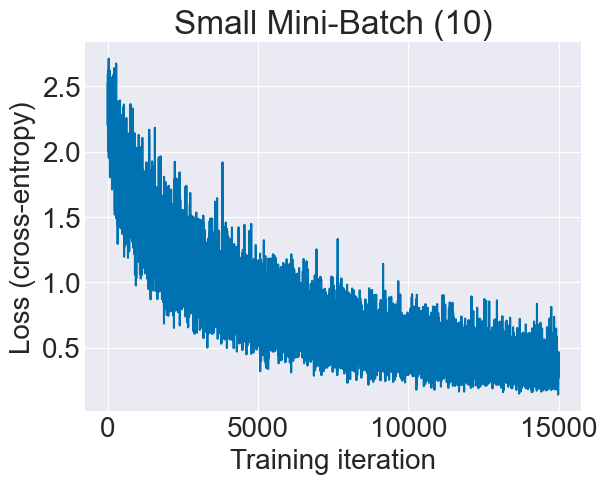

In [19]:
# YOUR CODE HERE
softmax_large = SoftmaxLayer(10)
loss_large = softmax_large.fit(
    x_dev,
    y_dev,
    n_epochs=600,
    mini_batch_sz=250, # Large Batch
    r_seed=0
)
# Small-batch
softmax_small = SoftmaxLayer(10)
loss_small = softmax_small.fit(
    x_dev,
    y_dev,
    n_epochs=600,
    mini_batch_sz=10, # Small Batch
    r_seed=0
)
# Plot
# Large batch plot
plt.figure()
plt.plot(loss_large)
plt.title("Large Mini-Batch (250)")
plt.xlabel("Training iteration")
plt.ylabel("Loss (cross-entropy)")
plt.show()

# Small batch plot
plt.figure()
plt.plot(loss_small)
plt.title("Small Mini-Batch (10)")
plt.xlabel("Training iteration")
plt.ylabel("Loss (cross-entropy)")
plt.show()

### 2e. Retraining the same net

Train 7 fresh softmax networks with default hyperparameters, except for `verbose=0`. Use the actual training set to train the networks rather than the dev set. Each time, compute and record the accuracy on the test set. After the 7 training sessions are over, print out all 7 accuracies.

In [22]:
# YOUR CODE HERE
accuracies = []

for i in range(7):
    # new network
    net = SoftmaxLayer(10)
    # train on training set
    net.fit(x_train, y_train, verbose=0)
    # predict on test set
    y_pred = net.predict(x_test)
    # Compute acc.
    acc = net.accuracy(y_test, y_pred)
    accuracies.append(acc)
# Print out
print("Test Accuracies:")
print(accuracies)

Test Accuracies:
[0.30133333333333334, 0.32133333333333336, 0.328, 0.33066666666666666, 0.30666666666666664, 0.316, 0.31466666666666665]


### 2f. Questions

**Question: 4:** What do you notice about the accuracies? Is this what you expected? Why does this happen?

**Answer 4:**

The accuracies are not identical but they are similar, which is expected since training is stochastic; weights are randomly initialized and mini-batches are sampled randomly.Even with the same hyperparameters, these small differences lead to slightly different final solutions and test accuracies.

### 2g. Train and optimize STL-10 dataset performance

As you've surely noticed, hyperparameters can drastically affect learning! 


Implement a grid search for the best **combinations** of hyperparameters

- learning rate,
- regularization
- batch size 

Fix the training duration to `75` epochs.

The grid search process should:

1. Fit the model with specific values of hyperparameters that we're testing (using the training set).
2. Compute the accuracy on the **training set**. 
3. Compute the accuracy on the **validation set.** 
4. Print out and record the best parameter combination as you go (that *improves* the **validation set accuracy**).
5. Wipe the weights clean (reinitialize them) every time you try new parameters. It's easiest just to create a new net object on each run.

Configure your search *in the way that we prefer from class* so that you get reproducible accuracy. For example, if your search prints out that the best hyperparameters give X% accuracy in the search, training a net with those same hyperparameters after the search is completed also gives you X% accuracy.

#### Suggestions

This can take quite a bit of simulation time! Here are some tips:
- I suggest using a "manual "coarse-to-fine search strategy. Try varying hyperparameters over many orders of magnitude, then follow up with a 2nd search that "zooms in" around the hyperparameters that gave you the best results from the first search, as determined by your print outs. **There is no need to implement a fully automated coarse-to-fine grid search here.** You can be informal and manually hard-code the coarse and fine hyperparameter choices. Abort searches prematurely if you feel there aren't productive (no reason to wait!). This can take however long or short that you want to dedicate. Remember, you are printing out the best parameter values on each run, so you can always just proceed with those.
- High learning rates don't really make sense. You'll know if your value is "high" if numpy complains about numerical issues.
- Your mini-batch sizes should be `<= N` and `>= 1`.
- Time single network runs with a few different batch sizes you plan on trying in your big search. This will help you figure out a ballpark estimate how long grid search will take (*you can decide whether to go eat dinner, run it overnight, etc.*). If it will take an unreasonable amount of time, reduce the number of parameters you try in one search.
- Think about whether you need *3 nested loops* or *a sequence of single loops*.
- Turn off print outs from `fit` (adjust `verbose` argument) and only print out things related to your search.
- Feel free to try a search with more than 75 training epochs for potentially better accuracy, but note that the search will take longer to complete.

**Important note:** I am not grading based on the number of hours your computer spends searching. I want to see that you successfully implemented the grid search to find progressively better hyperparameters on STL-10 and use the outcome to inform your ultimate training session that you use to evaluate predictions on the test set. You should be able to achieve ~30% accuracy without too much effort. *Getting full credit here does not require you spending hours of searching!*

In [27]:
# implementing grid search
learning_rates = [0.001, 0.01, 0.1] # range for learning rate
regularizations = [0.0, 0.1, 0.5] # range for regularization
batch_sizes = [32, 128, 256] # batch sizes

# Store best results
best_val_acc = 0
best_params = None

# Split data into sets
x_train, y_train, x_test, y_test, x_val, y_val, x_dev, y_dev = preprocess_data.load_stl10(n_train_samps=3000, n_test_samps=750, n_valid_samps=1000, n_dev_samps=250)

# Implement grid search over hyperparameters
for lr in learning_rates:
    for reg in regularizations:
        for batch_size in batch_sizes:
            print(f"Training with lr={lr}, reg={reg}, batch_size={batch_size}")
            # New model initialized
            model = SoftmaxLayer(num_output_units=10)
            # Train model
            model.fit(x_train, y_train, n_epochs=75, lr=lr, mini_batch_sz=batch_size, reg=reg, r_seed=0, verbose=0)
            y_train_pred = model.predict(x_train)
            train_acc = model.accuracy(y_train, y_train_pred)
            # Evaluate on val set
            y_val_pred = model.predict(x_val)
            val_acc = model.accuracy(y_val, y_val_pred)
            # Check if these are best params using logic
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_params = (lr, reg, batch_size, train_acc)
                print(f"New best params: lr={lr}, reg={reg}, batch_size={batch_size}, "f"train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")
print(f"Best Hyperparameters: lr={best_params[0]}, reg={best_params[1]}, "f"batch_size={best_params[2]}, train_acc={best_params[3]:.4f}, "f"val_acc={best_val_acc:.4f}")

Found cached numpy arrays the images and labels. Loading them...
Images are: (5000, 32, 32, 3)
Labels are: (5000,)


Training with lr=0.001, reg=0.0, batch_size=32
New best params: lr=0.001, reg=0.0, batch_size=32, train_acc=0.6423, val_acc=0.3290
Training with lr=0.001, reg=0.0, batch_size=128
New best params: lr=0.001, reg=0.0, batch_size=128, train_acc=0.5023, val_acc=0.3440
Training with lr=0.001, reg=0.0, batch_size=256
New best params: lr=0.001, reg=0.0, batch_size=256, train_acc=0.4477, val_acc=0.3550
Training with lr=0.001, reg=0.1, batch_size=32
Training with lr=0.001, reg=0.1, batch_size=128
Training with lr=0.001, reg=0.1, batch_size=256
New best params: lr=0.001, reg=0.1, batch_size=256, train_acc=0.4493, val_acc=0.3560
Training with lr=0.001, reg=0.5, batch_size=32
Training with lr=0.001, reg=0.5, batch_size=128
Training with lr=0.001, reg=0.5, batch_size=256
Training with lr=0.01, reg=0.0, batch_size=32
Training with lr=0.01, reg=0.0, batch_size=128
Training with lr=0.01, reg=0.0, batch_size=256
Training with lr=0.01, reg=0.1, batch_size=32
Training with lr=0.01, reg=0.1, batch_size=128

In [30]:
# YOUR CODE HERE
# intialize model
bestNet = SoftmaxLayer(num_output_units=10)
# Split data into training
x_train, y_train, x_test, y_test, x_val, y_val, x_dev, y_dev = preprocess_data.load_stl10(n_train_samps=3000, n_test_samps=750, n_valid_samps=1000, n_dev_samps=250)
# Train with same hyperparameters
bestNet.fit(x_train, y_train, n_epochs=75, lr=0.01, mini_batch_sz=256, reg=0.5, r_seed=0, verbose=0)
# Evaluate
y_val_pred = bestNet.predict(x_val)
val_acc = bestNet.accuracy(y_val, y_val_pred)
print(f"Validation Accuracy: {val_acc}")

Found cached numpy arrays the images and labels. Loading them...
Images are: (5000, 32, 32, 3)
Labels are: (5000,)
Validation Accuracy: 0.357


### 2i. Evaluate best model on test set

**Question 5:** Now that you have "good" parameter values recorded, train a new model with the best learning rate, regularization strength, and batch size values in the cell below. What accuracy do you get on the **test set**? How does this compare to chance performance?

*Recall: The test set should NOT be used in your grid search. It should only be processed once AFTER you conclude your grid search.*

**Answer 5:**

Accuracy on Test Set: 35.2%

Comparison: This is around 3 times higher than what you would expect with the change performance. Which highlights that our model is learning the dataset effectively, and our grid search has found the best hyperparameters that drive our accuracy outputs higher. 

In [31]:
# YOUR CODE HERE
bestNet = SoftmaxLayer(num_output_units=10)
# Split data into sets
x_train, y_train, x_test, y_test, x_val, y_val, x_dev, y_dev = preprocess_data.load_stl10(n_train_samps=3000, n_test_samps=750, n_valid_samps=1000, n_dev_samps=250)
# Train with best hyperparameters
bestNet.fit(x_train, y_train, n_epochs=75, lr=0.01, mini_batch_sz=256, reg=0.5, r_seed=0, verbose=0)
# Evaluate
y_test_pred = bestNet.predict(x_test)
test_acc = bestNet.accuracy(y_test, y_test_pred)
print(f"Test Accuracy: {test_acc}")

Found cached numpy arrays the images and labels. Loading them...
Images are: (5000, 32, 32, 3)
Labels are: (5000,)
Test Accuracy: 0.352


### 2j. Visualize learned weights

Run the following code that plots the network weights going to each output neuron. Depending on your network's hyperparameters, you might see something really cool! *If you see "static noise", that could be fine...only certain ranges of hyperparameters will produce clear visualizations below.* Include the plot in your submitted project to show me what you got!

**Note:** the quality of your visualizations will depend on:
- The quality of the hyperparameters that you got via grid search.
- How many epochs that you trained the network before plotting the weights

One extension idea: is to find the combination of the above that result in the best visualizations.

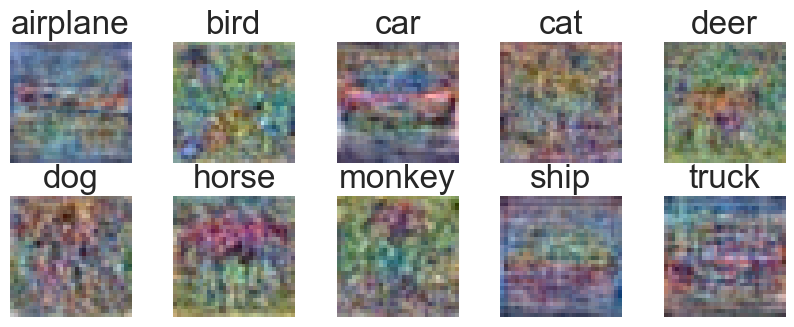

In [35]:
# Load in the class names
classes = np.loadtxt(os.path.join('data', 'stl10_binary', 'class_names.txt'), dtype=str)

# We don't care about the bias wt
wts = bestNet.wts
# Reshape the wt vectors into spatial 'image' configurations to visualization
wts = wts.reshape(32, 32, 3, 10)

# Make a large new empty figure/plot
plt.figure(figsize=(10, 4))

# Loop through each output neuron
for i in range(10):
  # Make a 2x5 grid of images
  plt.subplot(2, 5, i+1)

  # Rescale the weights to be between 0 and 255
  currImg = 255.0 * (wts[:, :, :, i].squeeze() - np.min(wts)) / (np.max(wts) - np.min(wts))

  plt.imshow(currImg.astype('uint8'))
  plt.axis('off')
  plt.title(classes[i])
plt.subplots_adjust(wspace=0.35, hspace=0)
plt.show()